In [5]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загрузка данных
data = pd.read_csv(r"C:\Users\veron\OneDrive\Desktop\учеба\train.csv")

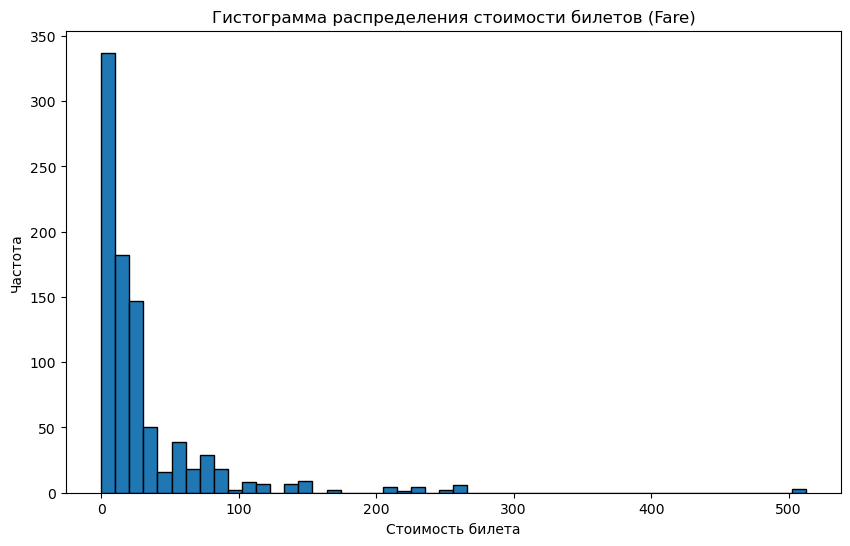

Статистический анализ столбца 'Fare':
Среднее значение: 32.20
Минимальное значение: 0.00
Максимальное значение: 512.33
Медианное значение: 14.45
Стандартное отклонение: 49.69
Квартили:
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: Fare, dtype: float64


In [7]:
# Шаг 3. Построить гистограмму по столбцу 'Fare'. Проанализировать статистические особенности по столбцу 'Fare'

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(data['Fare'].dropna(), bins=50, edgecolor='black')
plt.title('Гистограмма распределения стоимости билетов (Fare)')
plt.xlabel('Стоимость билета')
plt.ylabel('Частота')
plt.show()

# Статистический анализ столбца Fare
print("Статистический анализ столбца 'Fare':")
print(f"Среднее значение: {data['Fare'].mean():.2f}")
print(f"Минимальное значение: {data['Fare'].min():.2f}")
print(f"Максимальное значение: {data['Fare'].max():.2f}")
print(f"Медианное значение: {data['Fare'].median():.2f}")
print(f"Стандартное отклонение: {data['Fare'].std():.2f}")
print(f"Квартили:\n{data['Fare'].quantile([0.25, 0.5, 0.75])}")

Количество уникальных значений в Fare: 248

10 самых часто встречающихся значений:
Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
10.5000    24
7.9250     18
7.7750     16
7.2292     15
26.5500    15
Name: count, dtype: int64


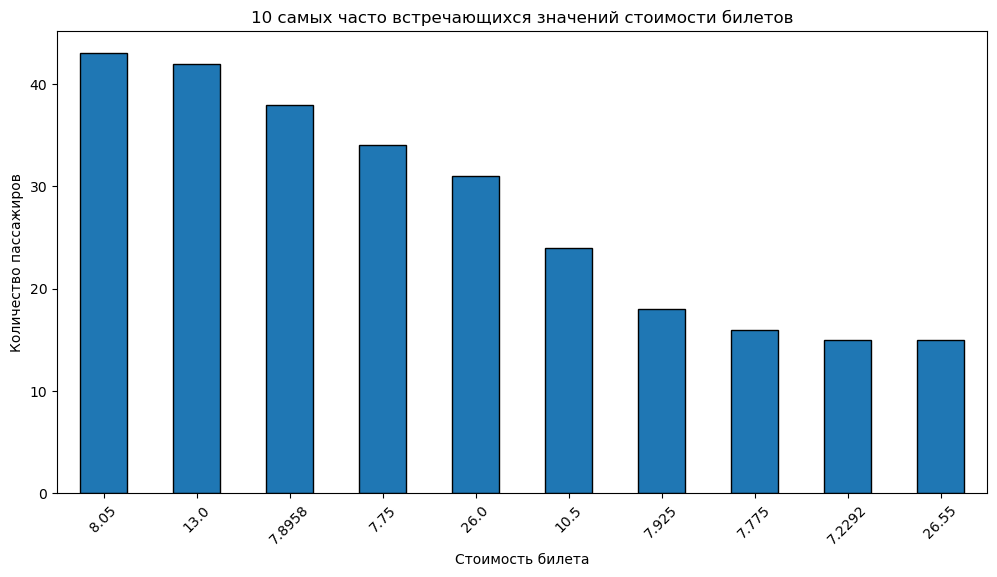

In [8]:
# Шаг 4. Рассчитать количество встречаемости каждого отдельного значения. Построить гистограмму по методу value_counts() (только 10 самых частых)

# Расчет частоты встречаемости значений в столбце Fare
fare_value_counts = data['Fare'].value_counts()
print("Количество уникальных значений в Fare:", len(fare_value_counts))
print("\n10 самых часто встречающихся значений:")
print(fare_value_counts.head(10))

# Построение гистограммы для 10 самых частых значений
plt.figure(figsize=(12, 6))
fare_value_counts.head(10).plot(kind='bar', edgecolor='black')
plt.title('10 самых часто встречающихся значений стоимости билетов')
plt.xlabel('Стоимость билета')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Шаг 5. Определите количество официально занятых кабин по данным в датасете

# Подсчет количества непустых значений в столбце Cabin
occupied_cabins = data['Cabin'].notna().sum()
print(f"Количество официально занятых кабин: {occupied_cabins}")
print(f"Всего пассажиров в датасете: {len(data)}")
print(f"Доля пассажиров с известными кабинами: {occupied_cabins/len(data)*100:.2f}%")

Количество официально занятых кабин: 204
Всего пассажиров в датасете: 891
Доля пассажиров с известными кабинами: 22.90%


In [10]:
# Шаг 6. Изучите датасет на наличие пропусков в каждом столбце. Заполните пропуски

# Проверка пропусков в каждом столбце
print("Пропуски в каждом столбце до заполнения:")
print(data.isnull().sum())

# Заполнение пропусков
data_clean = data.copy()

# Заполнение Age медианным значением 
data_clean['Age'] = data_clean['Age'].fillna(data_clean['Age'].median())

# Заполнение остальных полей самым часто встречающимся значением
for column in data_clean.columns:
    if data_clean[column].isnull().any():
        most_frequent = data_clean[column].mode()[0]
        data_clean[column] = data_clean[column].fillna(most_frequent)

print("\nПропуски в каждом столбце после заполнения:")
print(data_clean.isnull().sum())

Пропуски в каждом столбце до заполнения:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Пропуски в каждом столбце после заполнения:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [11]:
# Шаг 7. Выделить в переменную target столбец 'Survived'

target = data_clean['Survived']
print("Размерность target:", target.shape)
print("Распределение классов в target:")
print(target.value_counts())

Размерность target: (891,)
Распределение классов в target:
Survived
0    549
1    342
Name: count, dtype: int64


In [31]:
# Шаг 8. Добавить данные о себе и о двух известных людях в данный датасет

# Создание данных для добавления
# PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
new_passengers = pd.DataFrame({
    'PassengerId': [892, 893, 894],
    'Survived': [0, 0, 0],  # Временные значения, потом будем прогнозировать
    'Pclass': [2, 3, 1],
    'Name': ['Veronika, Miss. Your Name', 'DiCaprio, Mr. Leonardo', 'Winslet, Mrs. Kate'],
    'Sex': ['female', 'male', 'female'],
    'Age': [19, 51, 50],
    'SibSp': [0, 0, 1],
    'Parch': [0, 0, 1],
    'Ticket': ['123456', '789012', '345678'],
    'Fare': [35.0, 7.0, 100.0],
    'Cabin': [None, 'None', 'B52'],
    'Embarked': ['S', 'S', 'C']
})

# Добавление данных в конец датасета
data_with_new = pd.concat([data_clean, new_passengers], ignore_index=True)

# Проверка, что данные оказались в конце
print("Последние 5 строк датасета:")
print(data_with_new.tail())

Последние 5 строк датасета:
     PassengerId  Survived  Pclass                       Name     Sex   Age  \
889          890         1       1      Behr, Mr. Karl Howell    male  26.0   
890          891         0       3        Dooley, Mr. Patrick    male  32.0   
891          892         0       2  Veronika, Miss. Your Name  female  19.0   
892          893         0       3     DiCaprio, Mr. Leonardo    male  51.0   
893          894         0       1         Winslet, Mrs. Kate  female  50.0   

     SibSp  Parch  Ticket    Fare    Cabin Embarked  
889      0      0  111369   30.00     C148        C  
890      0      0  370376    7.75  B96 B98        Q  
891      0      0  123456   35.00     None        S  
892      0      0  789012    7.00     None        S  
893      1      1  345678  100.00      B52        C  


In [32]:
# Шаг 9. Преобразовывать значения столбцов с текстовыми значениями в численные значения с помощью OneHotEncoder

# Сохраняем копию для дальнейшего использования
data_encoded = data_with_new.copy()

# One-hot encoding для категориальных переменных
cat_columns = ['Sex', 'Embarked', 'Pclass']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(data_encoded[cat_columns])

# Создаем имена для новых колонок
feature_names = encoder.get_feature_names_out(cat_columns)

# Создаем DataFrame с закодированными значениями
encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=data_encoded.index)

# Объединяем с исходным DataFrame
data_encoded = pd.concat([data_encoded.drop(cat_columns, axis=1), encoded_df], axis=1)

print("Датасет после OneHotEncoder:")
print(data_encoded.head())
print("\nРазмерность после кодирования:", data_encoded.shape)

Датасет после OneHotEncoder:
   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

    Age  SibSp  Parch            Ticket     Fare    Cabin  Sex_female  \
0  22.0      1      0         A/5 21171   7.2500  B96 B98         0.0   
1  38.0      1      0          PC 17599  71.2833      C85         1.0   
2  26.0      0      0  STON/O2. 3101282   7.9250  B96 B98         1.0   
3  35.0      1      0            113803  53.1000     C123         1.0   
4  35.0      0      0            373450   8.0500  B96 B98         0.0   

   Sex_male  Embarked_C  Embarked_Q  Embarked_S  Pclass_1

In [33]:
# Шаг 10. Удалить из датасета поля, которые не пригодны для построения прогнозной модели

columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data_model = data_encoded.drop(columns=columns_to_drop)

print("Датасет после удаления непригодных полей:")
print(data_model.head())
print("\nОставшиеся столбцы:", data_model.columns.tolist())

Датасет после удаления непригодных полей:
   Survived   Age  SibSp  Parch     Fare  Sex_female  Sex_male  Embarked_C  \
0         0  22.0      1      0   7.2500         0.0       1.0         0.0   
1         1  38.0      1      0  71.2833         1.0       0.0         1.0   
2         1  26.0      0      0   7.9250         1.0       0.0         0.0   
3         1  35.0      1      0  53.1000         1.0       0.0         0.0   
4         0  35.0      0      0   8.0500         0.0       1.0         0.0   

   Embarked_Q  Embarked_S  Pclass_1  Pclass_2  Pclass_3  
0         0.0         1.0       0.0       0.0       1.0  
1         0.0         0.0       1.0       0.0       0.0  
2         0.0         1.0       0.0       0.0       1.0  
3         0.0         1.0       1.0       0.0       0.0  
4         0.0         1.0       0.0       0.0       1.0  

Оставшиеся столбцы: ['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclas

In [34]:
# Шаг 11. Отделить в выборку для построения прогноза добавленные в датасет строки

x_pred = data_model[-3:]
print("Выборка для прогноза (3 последние строки):")
print(x_pred)
print("\nРазмерность x_pred:", x_pred.shape)

Выборка для прогноза (3 последние строки):
     Survived   Age  SibSp  Parch   Fare  Sex_female  Sex_male  Embarked_C  \
891         0  19.0      0      0   35.0         1.0       0.0         0.0   
892         0  51.0      0      0    7.0         0.0       1.0         0.0   
893         0  50.0      1      1  100.0         1.0       0.0         1.0   

     Embarked_Q  Embarked_S  Pclass_1  Pclass_2  Pclass_3  
891         0.0         1.0       0.0       1.0       0.0  
892         0.0         1.0       0.0       0.0       1.0  
893         0.0         0.0       1.0       0.0       0.0  

Размерность x_pred: (3, 13)


In [35]:
# Шаг 12. Разделить остальной датасет на обучающую и тестовую выборки

# Отделяем добавленные строки от основного датасета
data_main = data_model[:-3]

# Разделяем на признаки и целевую переменную
X = data_main.drop('Survived', axis=1)
y = data_main['Survived']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки: (712, 12)
Размер тестовой выборки: (179, 12)

Распределение классов в обучающей выборке:
Survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
Survived
0    0.586592
1    0.413408
Name: proportion, dtype: float64


In [36]:
# Шаг 13. Создайте и обучите модель RandomForestClassifier

# Создание модели
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучение модели
rf_model.fit(X_train, y_train)
print("Модель RandomForestClassifier успешно обучена")

Модель RandomForestClassifier успешно обучена


In [37]:
# Шаг 14. Оценить качество обучения

# Предсказания на обучающей выборке
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Предсказания на тестовой выборке
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Точность на обучающей выборке: {train_accuracy*100:.2f}%")
print(f"Точность на тестовой выборке: {test_accuracy*100:.2f}%")

Точность на обучающей выборке: 97.89%
Точность на тестовой выборке: 82.12%


In [38]:
# Шаг 15. Произвести прогнозирование выживания для людей, добавленных в пункте 8

# Убираем целевой столбец из данных для прогноза
x_pred_features = x_pred.drop('Survived', axis=1)

# Прогнозирование
predictions = rf_model.predict(x_pred_features)

# Вывод результатов
print("Прогноз выживания для добавленных пассажиров:")
print(f"Пассажир 1 (Veronika): {'Выжил' if predictions[0] == 1 else 'Не выжил'}")
print(f"Пассажир 2 (DiCaprio): {'Выжил' if predictions[1] == 1 else 'Не выжил'}")
print(f"Пассажир 3 (Winslet): {'Выжил' if predictions[2] == 1 else 'Не выжил'}")

# Добавим вероятности прогнозов
probabilities = rf_model.predict_proba(x_pred_features)
print("\nВероятности прогнозов:")
for i, prob in enumerate(probabilities):
    print(f"Пассажир {i+1}: Вероятность не выжить = {prob[0]:.3f}, Вероятность выжить = {prob[1]:.3f}")

Прогноз выживания для добавленных пассажиров:
Пассажир 1 (Veronika): Выжил
Пассажир 2 (DiCaprio): Не выжил
Пассажир 3 (Winslet): Выжил

Вероятности прогнозов:
Пассажир 1: Вероятность не выжить = 0.015, Вероятность выжить = 0.985
Пассажир 2: Вероятность не выжить = 0.960, Вероятность выжить = 0.040
Пассажир 3: Вероятность не выжить = 0.060, Вероятность выжить = 0.940


In [39]:
# Шаг 16. Сделать выводы о результатах прогнозирования

print("ВЫВОДЫ О РЕЗУЛЬТАТАХ ПРОГНОЗИРОВАНИЯ:")
print("="*50)
print(f"1. Качество модели: модель показала точность {train_accuracy*100:.2f}% на обучающей выборке и {test_accuracy*100:.2f}% на тестовой.")
if train_accuracy - test_accuracy > 0.1:
    print("   Наблюдается небольшое переобучение модели (разница > 10%).")
else:
    print("   Модель показывает хорошую обобщающую способность.")

print(f"\n2. Результаты прогноза для добавленных пассажиров:")
for i, pred in enumerate(predictions):
    name = ["Veronika", "DiCaprio", "Winslet"][i]
    result = "выживет" if pred == 1 else "не выживет"
    prob = probabilities[i][1] if pred == 1 else probabilities[i][0]
    print(f"   - {name} с вероятностью {prob:.2%} {result} на Титанике")

print("\n3. Анализ факторов, влияющих на прогноз:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("   Наиболее важные факторы при прогнозировании:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.3f}")

ВЫВОДЫ О РЕЗУЛЬТАТАХ ПРОГНОЗИРОВАНИЯ:
1. Качество модели: модель показала точность 97.89% на обучающей выборке и 82.12% на тестовой.
   Наблюдается небольшое переобучение модели (разница > 10%).

2. Результаты прогноза для добавленных пассажиров:
   - Veronika с вероятностью 98.50% выживет на Титанике
   - DiCaprio с вероятностью 96.00% не выживет на Титанике
   - Winslet с вероятностью 94.00% выживет на Титанике

3. Анализ факторов, влияющих на прогноз:
   Наиболее важные факторы при прогнозировании:
   - Fare: 0.249
   - Age: 0.248
   - Sex_male: 0.151
